In [1]:
import sys
!{sys.executable} -m pip install torch torch-geometric


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: E:\Final_Year_Project\gnn_env\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import torch
from torch.nn import Linear
import torch.nn.functional as F

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

import pandas as pd
import pickle

E:\Final_Year_Project\gnn_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("../data/processed/chembl_molecular_graphs.pkl", "rb") as f:
    graphs = pickle.load(f)

df = pd.read_csv("../data/raw/chembl/chembl_ic50_5000.csv")

print(len(graphs), len(df))

4780 4780


In [4]:
data_list = []

for graph, label in zip(graphs, df["standard_value"]):
    x = torch.tensor(graph["nodes"], dtype=torch.float).view(-1, 1)
    edge_index = torch.tensor(graph["edges"], dtype=torch.long).t().contiguous()
    y = torch.tensor([label], dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, y=y)
    data_list.append(data)

print("Total graphs:", len(data_list))

Total graphs: 4780


In [5]:
loader = DataLoader(data_list, batch_size=32, shuffle=True)

C:\Users\Fathima\AppData\Local\Temp\ipykernel_2900\1401854867.py:1: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(data_list, batch_size=32, shuffle=True)


In [6]:
class MolecularGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(1, 64)
        self.conv2 = GCNConv(64, 128)
        self.fc = Linear(128, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        out = self.fc(x)

        return out, x  # x = embedding


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MolecularGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

In [8]:
losses = []

model.train()
for epoch in range(10):
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        pred, _ = model(batch)

        loss = criterion(pred.view(-1), batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 132723504554834272.0000
Epoch 2, Loss: 132723476831473088.0000
Epoch 3, Loss: 132723463159178496.0000
Epoch 4, Loss: 132723431891073472.0000
Epoch 5, Loss: 132723304326828480.0000
Epoch 6, Loss: 132723181808931152.0000
Epoch 7, Loss: 132723067476608096.0000
Epoch 8, Loss: 132722794993853120.0000
Epoch 9, Loss: 132722677726207296.0000
Epoch 10, Loss: 132722092769778048.0000


In [9]:
model.eval()
drug_embeddings = []

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        _, emb = model(batch)
        drug_embeddings.append(emb.cpu())

drug_embeddings = torch.cat(drug_embeddings, dim=0)
print("Drug embedding shape:", drug_embeddings.shape)


Drug embedding shape: torch.Size([4780, 128])


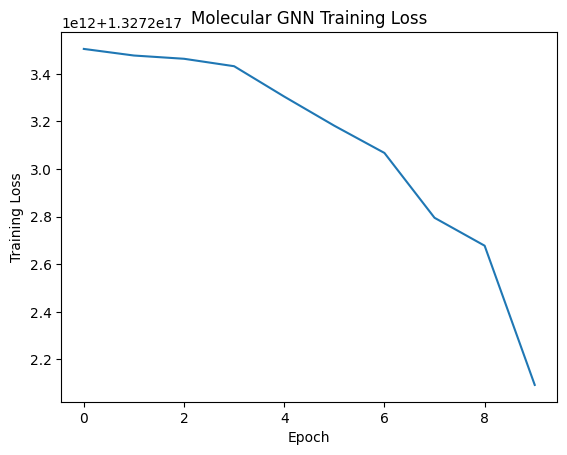

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Molecular GNN Training Loss")
plt.show()

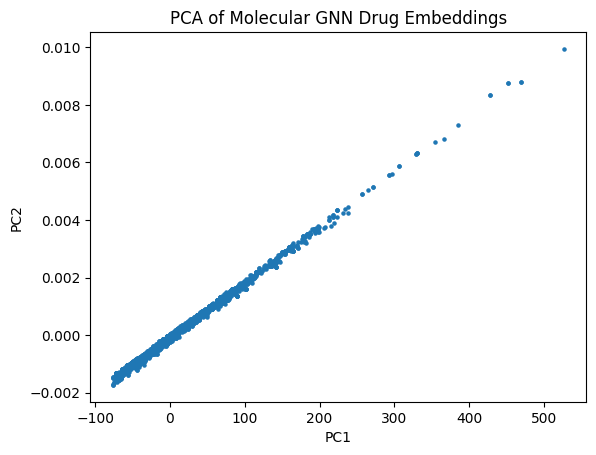

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

emb_np = drug_embeddings.numpy()

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_np)

plt.figure()
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Molecular GNN Drug Embeddings")
plt.show()

In [12]:
torch.save(
    drug_embeddings,
    "../outputs/features/drug_embeddings.pt"
)

print("Drug embeddings saved")

Drug embeddings saved
